# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Muhammad Almustofa Khanafi]
- **Email:** [23040700074@student.umj.ac.id]
- **ID Dicoding:** [muhammad_almustofa_khanafi_EUa8]

## Menentukan Pertanyaan Bisnis

- Berdasarkan data pada periode Januari–Maret 2012, pada hari apa total transaksi penyewaan tercatat paling tinggi ?
- Khusus pada periode Maret 2012, pada rentang jam berapakah total transaksi penyewaan mencapai volume tertinggi?

## Import Semua Packages/Library yang Digunakan

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Memuat tabel Day


In [4]:
day_df = pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Memuat tabel Hour

In [5]:
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dari kode day_df menampilkan 5 baris dataframe yang isinya seperti pada tabel diatas.
- Dari kode hour_df menampilkan 5 baris dataframe yang isinya seperti pada tabel diatas.

### Assessing Data

Menilai Data day_df

In [6]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [7]:
print("Jumlah Duplikasi : ", day_df.duplicated().sum())
day_df.describe()

Jumlah Duplikasi :  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Menilai Data hour_df

In [8]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Dapat perhatikan, jumlah data pada hour_df telah lengkap atau dengan kata lain tidak ada missing value di dalamnya. Akan tetapi, terdapat kesalahan tipe data untuk kolom dteday. Kolom tersebut harusnya direpresentasikan sebagai tipe data datetime, bukan object (ini digunakan untuk tipe data string).

Berikutnya, kita perlu memeriksa duplikasi dan ringkasan parameter statistik dari kolom numerik pada hour_df. Proses ini dilakukan dengan menjalankan kode berikut:

In [9]:
print("Jumlah Duplikasi : ", hour_df.duplicated().sum())
hour_df.describe()

Jumlah Duplikasi :  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Dapat perhatikan, jumlah data pada day_df telah lengkap atau dengan kata lain tidak ada missing value di dalamnya. Akan tetapi, terdapat kesalahan tipe data untuk kolom dteday. Kolom tersebut harusnya direpresentasikan sebagai tipe data datetime, bukan object (ini digunakan untuk tipe data string).

- Dan untuk hour_df memiliki masalah yang sama, yaitu terdapat kesalahan tipe data untuk kolom dteday. Yang harusnya kolom tersebut berisi tipe data datetime, bukan object.

### Cleaning Data

Membersihkan Data day_df

In [10]:
datetime_columns = ["dteday"]

for column in datetime_columns:
    day_df[column] = pd.to_datetime(day_df[column])

In [11]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

Membersihkan Data hour_day

In [12]:
hour_df = pd.read_csv('hour.csv')
datetime_columns = ["dteday"]

for column in datetime_columns:
    hour_df[column] = pd.to_datetime(hour_df[column])

In [13]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Untuk mengatasinya masalah pada tipe data day_df, disini saya mengganti tipe datanya yang dari object ke datetime dengan menggunakan function to_datetime().
- Untuk mengatasinya masalah pada tipe data hour_df, disini saya mengganti tipe datanya yang dari object ke datetime dengan menggunakan function to_datetime().

## Exploratory Data Analysis (EDA)

### Explore Data day_df

In [14]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [15]:

day_df["dteday"] = pd.to_datetime(day_df["dteday"])


start_date = pd.to_datetime("2012-01-01")
end_date = pd.to_datetime("2012-03-31")


jan_mar_2012_df = day_df[(day_df["dteday"] >= start_date) & (day_df["dteday"] <= end_date)].copy()

urutan_hari = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
jan_mar_2012_df["weekday_name"] = pd.Categorical(
    jan_mar_2012_df["weekday"].map({
        0: "Sunday", 1: "Monday", 2: "Tuesday",
        3: "Wednesday", 4: "Thursday", 5: "Friday", 6: "Saturday"
    }),
    categories=urutan_hari,
    ordered=True
)

In [18]:
print("--- Aggregasi Penyewaan per Hari (Januari–Maret 2012) ---")

day_agg = jan_mar_2012_df.groupby("weekday_name", observed=False).agg({
    "cnt": ["sum", "mean", "max", "min"]
})

display(day_agg.sort_values(by=("cnt", "sum"), ascending=False))

--- Aggregasi Penyewaan per Hari (Januari–Maret 2012) ---


cnt                         
                sum         mean   max   min
weekday_name                                
Thursday      59962  4612.461538  6871  3005
Friday        55516  4270.461538  8362  3163
Tuesday       55052  4234.769231  6093  2236
Wednesday     53504  4115.692308  6312  1834
Saturday      50016  3847.384615  7836  1301
Monday        47680  3667.692308  6153  1951
Sunday        43026  3309.692308  5892  1529

## Explore data hour_df

In [19]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [25]:
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])


start_date_hour = pd.to_datetime("2012-03-01")
end_date_hour = pd.to_datetime("2012-03-31")


mar_2012_df = hour_df[(hour_df["dteday"] >= start_date_hour) & (hour_df["dteday"] <= end_date_hour)].copy()



In [24]:
print("--- Aggregasi Penyewaan per Jam (Maret 2012) ---")

hour_agg = mar_2012_df.groupby("hr").agg({
    "cnt": ["sum", "mean", "max", "min"]
})

display(hour_agg.sort_values(by=("cnt", "sum"), ascending=False).head(10))

--- Aggregasi Penyewaan per Jam (Maret 2012) ---


cnt                      
      sum        mean  max  min
hr                             
17  17333  559.129032  957  115
18  16853  543.645161  830  137
8   13811  445.516129  662   48
19  11666  376.322581  686  132
16  11341  365.838710  685   50
13   9480  305.806452  686  120
15   9336  301.161290  679   78
12   9214  297.225806  651  137
14   8905  287.258065  690  128
9    8171  263.580645  380   90

**Insight:**
- Tren Penyewaan Harian (Januari–Maret 2012): Volume penyewaan sepeda, baik secara total (sum) maupun rata-rata (mean), secara konsisten didominasi oleh hari kerja (Senin–Jumat). Sebaliknya, hari Minggu mencatatkan angka penyewaan terendah. Pola ini mengindikasikan bahwa mayoritas pengguna menyewa sepeda untuk mobilitas atau komuter harian yang rutin, dibandingkan untuk kebutuhan rekreasi di akhir pekan.

- Puncak Jam Operasional (Maret 2012): Akumulasi transaksi penyewaan tertinggi terkonsentrasi pada rentang rush hour atau jam sibuk, yaitu pukul 17:00 dan 18:00 (jam pulang beraktivitas), disusul oleh pukul 08:00 (jam berangkat). Temuan ini memperkuat insight sebelumnya, menegaskan tingginya permintaan operasional yang sangat terikat dengan jadwal keberangkatan dan kepulangan para pekerja atau pelajar.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berdasarkan data pada periode Januari–Maret 2012, pada hari apa total transaksi penyewaan tercatat paling tinggi ?

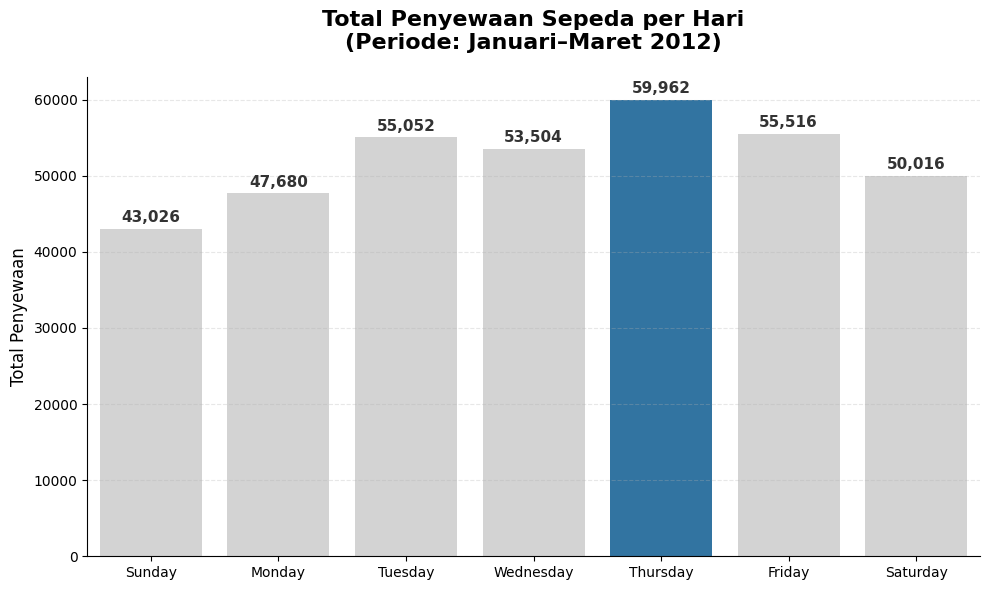

In [26]:
day_plot_data = jan_mar_2012_df.groupby("weekday_name", observed=False)["cnt"].sum().reset_index()


max_cnt = day_plot_data["cnt"].max()
colors = ["#1f77b4" if val == max_cnt else "#d3d3d3" for val in day_plot_data["cnt"]]


plt.figure(figsize=(10, 6)) #

ax = sns.barplot(
    x="weekday_name",
    y="cnt",
    data=day_plot_data,
    palette=colors,
    hue="weekday_name",
    legend=False
)


plt.title("Total Penyewaan Sepeda per Hari\n(Periode: Januari–Maret 2012)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(None)
plt.ylabel("Total Penyewaan", fontsize=12)


for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11, fontweight='bold', color='#333333')


sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

### Pertanyaan 2: Khusus pada periode Maret 2012, pada rentang jam berapakah total transaksi penyewaan mencapai volume tertinggi?

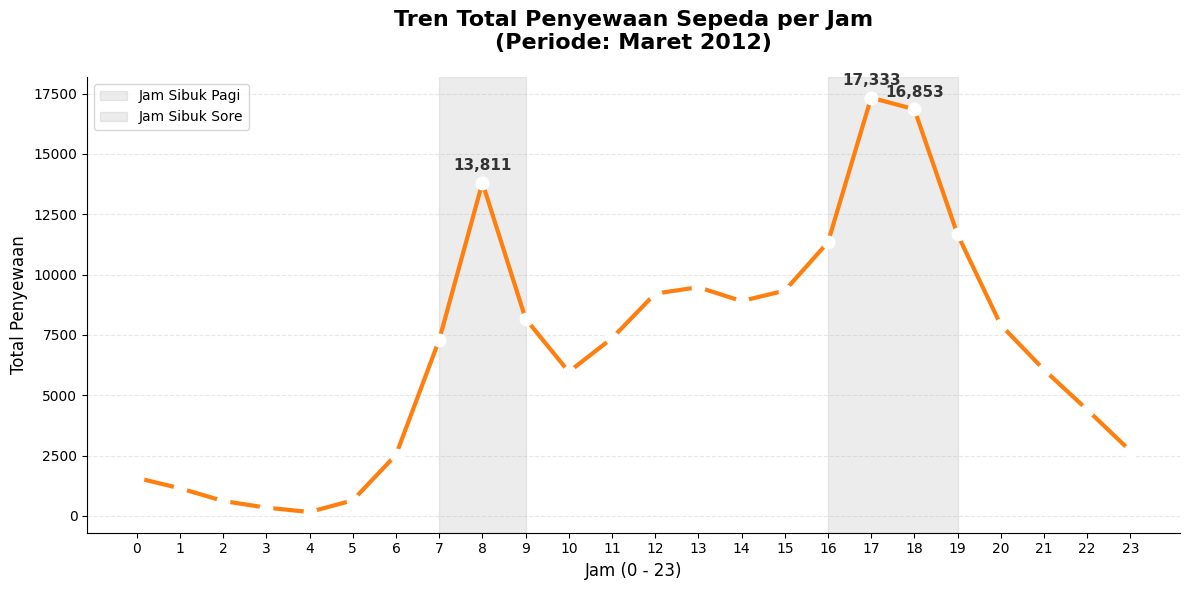

In [28]:


hour_plot_data = mar_2012_df.groupby("hr")["cnt"].sum().reset_index()

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    x="hr",
    y="cnt",
    data=hour_plot_data,
    color="#ff7f0e",
    linewidth=3,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2
)

plt.axvspan(7, 9, color='gray', alpha=0.15, label='Jam Sibuk Pagi')
plt.axvspan(16, 19, color='gray', alpha=0.15, label='Jam Sibuk Sore')

top_3_hours = hour_plot_data.nlargest(3, 'cnt')
for index, row in top_3_hours.iterrows():
    plt.text(
        row['hr'],
        row['cnt'] + (hour_plot_data['cnt'].max() * 0.03),
        f"{int(row['cnt']):,}",
        ha='center',
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )

plt.title("Tren Total Penyewaan Sepeda per Jam\n(Periode: Maret 2012)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Jam (0 - 23)", fontsize=12)
plt.ylabel("Total Penyewaan", fontsize=12)
plt.xticks(range(0, 24))

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.grid(axis='x', visible=False)
plt.legend(loc='upper left')
plt.tight_layout()

plt.show()

**Insight:**
- Penurunan Volume Akhir Pekan (Januari–Maret 2012): Tren penyewaan harian menunjukkan penurunan aktivitas yang signifikan saat memasuki akhir pekan, dengan volume transaksi terendah tercatat pada hari Minggu. Pola ini mengonfirmasi bahwa mayoritas penggunaan layanan berpusat pada hari kerja (Senin–Jumat) untuk kebutuhan komuter rutin.

- Pola Bimodal Jam Operasional (Maret 2012): Distribusi penyewaan per jam membentuk pola bimodal (dua puncak aktivitas) yang sangat sejalan dengan ritme jam sibuk (rush hour). Lonjakan pertama terjadi pada pukul 08:00 pagi (waktu berangkat), dan mencapai titik puncak tertinggi pada pukul 17:00 hingga 18:00 sore (waktu pulang). Sebaliknya, aktivitas penyewaan berada di titik nadir atau mendekati nol pada rentang tengah malam hingga menjelang subuh (00:00–05:00).

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1 :
Berdasarkan agregasi data periode Januari–Maret 2012, volume transaksi penyewaan didominasi oleh hari kerja (Senin–Jumat), dengan titik terendah (trough) terjadi secara konsisten pada hari Minggu.

  Interpretasi
  Pola penurunan drastis di akhir pekan ini mengindikasikan bahwa layanan penyewaan sepeda saat ini memiliki ketergantungan tinggi pada demografi komuter (pekerja atau pelajar). Mereka menggunakan sepeda sebagai moda transportasi harian yang esensial (first/last-mile transit), bukan sebagai sarana rekreasi santai.

  Rekomendasi Tindakan
  - Untuk menstimulasi permintaan dan memaksimalkan utilitas armada (fleet utilization) di hari Minggu, manajemen disarankan untuk melakukan penetrasi ke segmen pasar rekreasi. Langkah konkret yang bisa diambil meliputi:

  - Meluncurkan kampanye promosi bertema rekreasi, seperti "Family Weekend Pass" atau "Sunday City Explorer" dengan tarif bundling khusus.

  - Menjalin kemitraan (partnership) dengan taman kota atau pusat perbelanjaan untuk menyediakan pop-up station di titik-titik keramaian akhir pekan.

  - Mengalihkan anggaran pemasaran digital secara spesifik pada hari Jumat malam hingga Sabtu untuk mengingatkan pengguna tentang promo akhir pekan.

- Conclution pertanyaan 2 : Sepanjang bulan Maret 2012, distribusi penyewaan per jam membentuk pola bimodal (dua puncak). Lonjakan tertinggi terjadi pada rush hour sore pukul 17:00–18:00, diikuti puncak kedua pada rush hour pagi pukul 08:00. Sebaliknya, aktivitas terhenti hampir sepenuhnya pada pukul 00:00–05:00.

  Interpretasi
  Konsentrasi aktivitas pada dua titik waktu ini memperkuat kesimpulan pertama, yaitu pengguna sangat bergantung pada sepeda untuk mengejar ketepatan waktu saat jam masuk dan pulang kantor/kampus. Lonjakan sore yang lebih tinggi dari pagi hari dapat disebabkan oleh preferensi pengguna yang lebih fleksibel saat pulang (bisa mampir ke tempat lain terlebih dahulu) dibandingkan saat berangkat yang terburu-buru.

  Rekomendasi Tindakan
  - Tingginya volume transaksi pada jam sibuk memerlukan antisipasi operasional yang presisi untuk menjaga kepuasan pelanggan:

  - Distribusi Armada Dinamis (Rebalancing): Tim lapangan harus didistribusikan untuk memindahkan sepeda dari stasiun yang menumpuk ke stasiun di area transit utama (seperti stasiun kereta atau halte bus) selambat-lambatnya pukul 07:30 dan 16:30.

  - Manajemen Antrean: Mengalokasikan staf tambahan di lapangan atau memastikan sistem transaksi otomatis server (backend) memiliki kapasitas bandwidth yang ditingkatkan khusus pada pukul 17:00–18:00 untuk mencegah error sistem.

  - Jadwal Pemeliharaan Efektif: Menginstruksikan tim teknisi agar jadwal perbaikan, pembersihan, dan inspeksi sepeda dilakukan secara eksklusif pada rentang jam mati (00:00–05:00) agar seluruh armada siap pakai saat pagi hari.